Pima Dataset Cleaned.
Frankfurt Dataset Cleaned.
Risk Prediction Dataset Cleaned.

All datasets have been cleaned and saved as 'cleaned_...' files.
--- Loading Datasets ---

--- [EDA] Clinical Data Summary ---
       Pregnancies      Glucose  BloodPressure  SkinThickness      Insulin  \
count  1135.000000  1135.000000    1135.000000    1135.000000  1135.000000   
mean      3.971806   121.451982      72.818502      29.228194   136.224670   
std       3.393257    30.317967      11.967350       8.565542    71.593932   
min       0.000000    44.000000      24.000000       7.000000    14.000000   
25%       1.000000   100.000000      65.000000      27.000000   125.000000   
50%       3.000000   117.000000      72.000000      29.000000   125.000000   
75%       6.000000   140.000000      80.000000      31.000000   126.000000   
max      17.000000   199.000000     122.000000     110.000000   846.000000   

               BMI  DiabetesPedigreeFunction          Age      Outcome  
count  1135.00

/tmp/ipykernel_2494/1270285754.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=clinical_df, palette='viridis')



--- Generating Bivariate Analysis Plots ---


/tmp/ipykernel_2494/1270285754.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Glucose', data=clinical_df, ax=axes[0], palette='Set1')



--- Generating Outlier Detection Boxplot ---

--- Preprocessing Data ---

--- Training Models ---

--- Comparative Model Evaluation ---
Random Forest Analysis Complete.
SVM Analysis Complete.
Logistic Regression Analysis Complete.

                  Model  Accuracy  Precision    Recall  F1-Score
0        Random Forest  0.872247   0.845070  0.769231  0.805369
1                  SVM  0.784141   0.723077  0.602564  0.657343
2  Logistic Regression  0.779736   0.712121  0.602564  0.652778

--- Random Forest Feature Importance Analysis ---

Feature Importances:
                 Feature  Importance
                 Glucose    0.257758
                     BMI    0.176149
                     Age    0.131017
DiabetesPedigreeFunction    0.121263
           BloodPressure    0.089334
             Pregnancies    0.084288
           SkinThickness    0.071072
                 Insulin    0.069118


/tmp/ipykernel_2494/1270285754.py:235: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_importance_df, palette='viridis')



--- Plotting Random Forest Confusion Matrix (image_0.png replica) ---
--- [NEW] Random Forest Analysis and Confusion Matrix Visualization complete ---


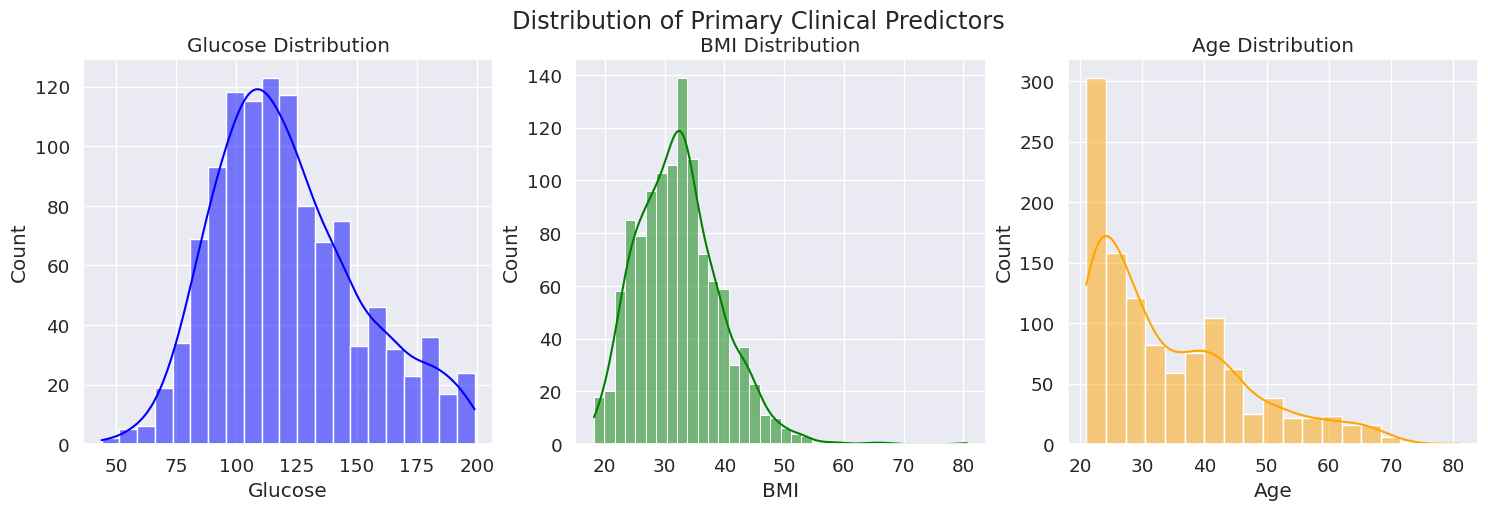

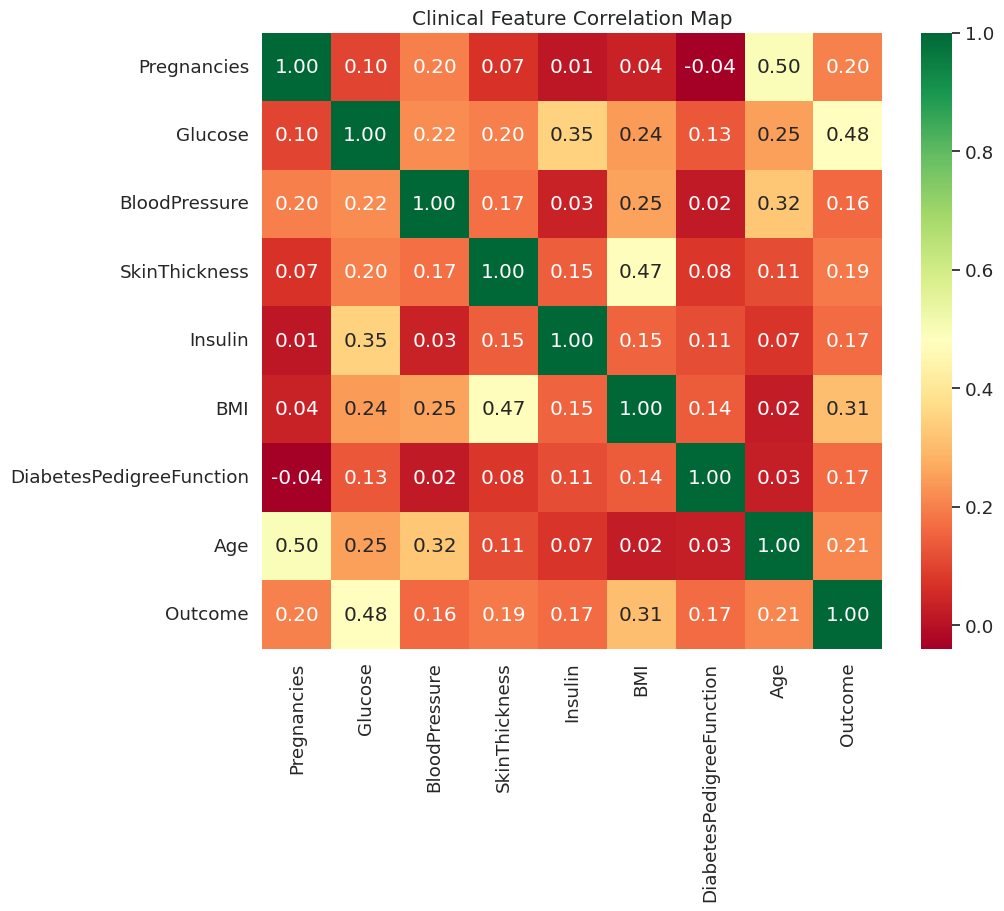

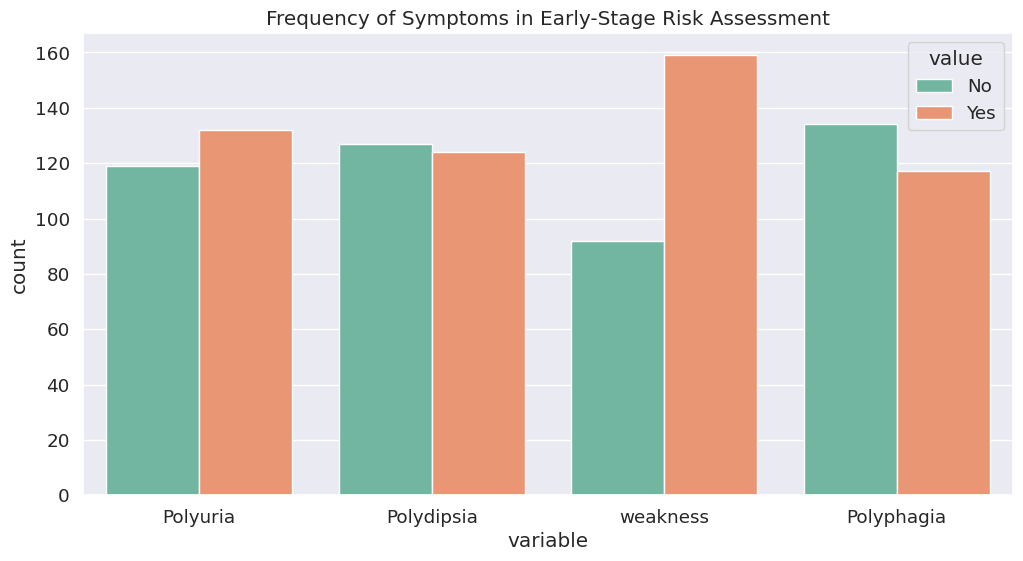

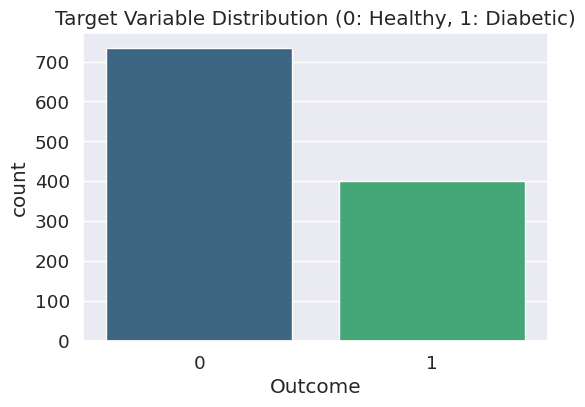

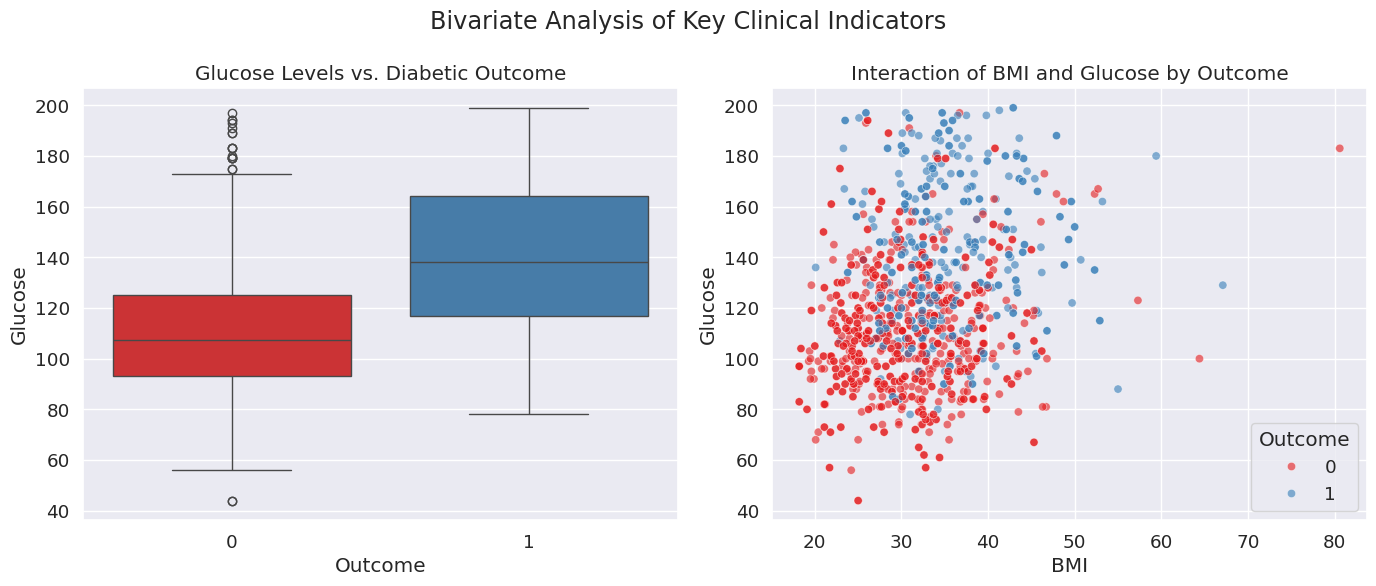

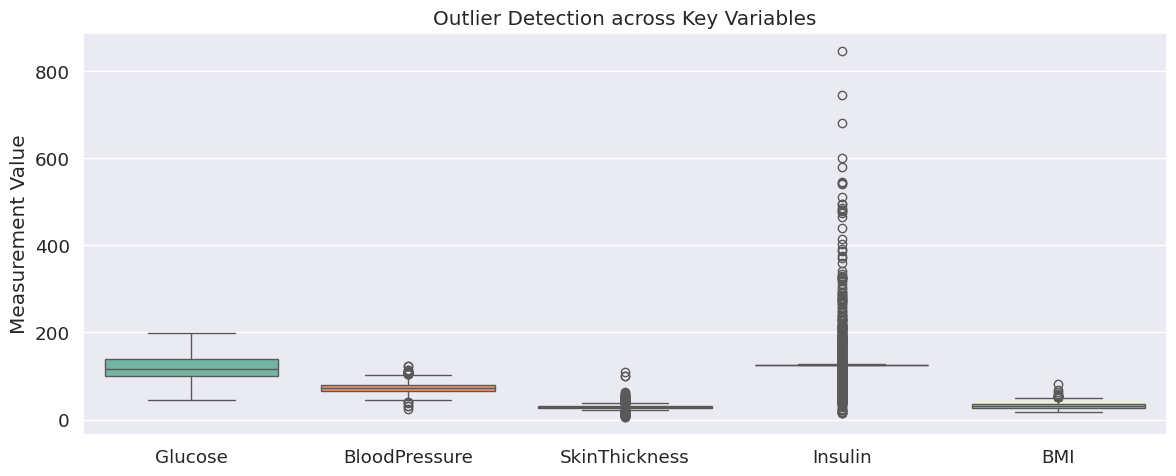

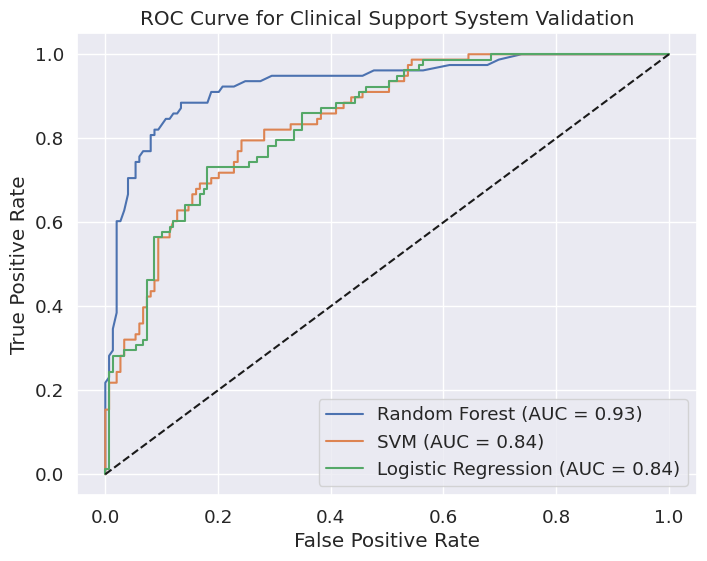

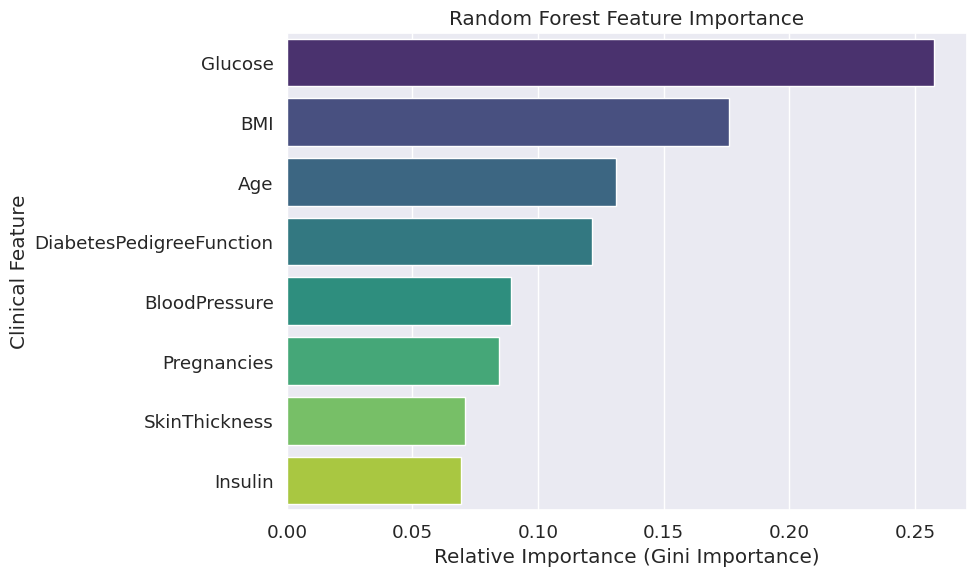

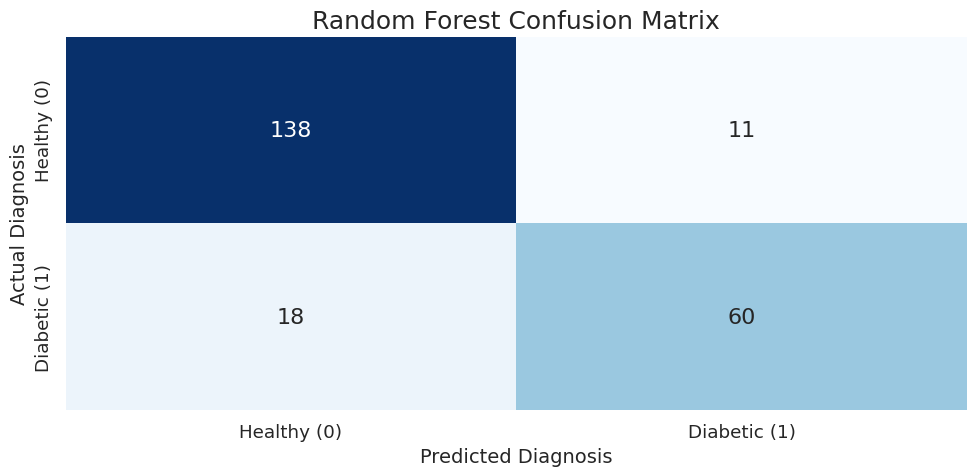

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# 1. Clean: Pima Indians Diabetes Database
def clean_pima_data(file_path):
    df = pd.read_csv(file_path)

    # Remove duplicates
    df = df.drop_duplicates()

    # In medical data, 0 is often a placeholder for missing values in these columns
    cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

    for col in cols_to_fix:
        # Replace 0 with NaN
        df[col] = df[col].replace(0, np.nan)
        # Impute NaN with the median of the column
        df[col] = df[col].fillna(df[col].median())

    df.to_csv('cleaned_Pima_Indians_Diabetes_Database.csv', index=False)
    print("Pima Dataset Cleaned.")
    return df

# 2. Clean: Frankfurt Hospital Diabetes Dataset
def clean_frankfurt_data(file_path):
    df = pd.read_csv(file_path)

    # Remove duplicates (This dataset often has many)
    df = df.drop_duplicates()

    # Handle missing/zero values same as Pima
    cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    for col in cols_to_fix:
        df[col] = df[col].replace(0, np.nan)
        df[col] = df[col].fillna(df[col].median())

    df.to_csv('cleaned_Frankfurt_Hospital_Diabetes_Dataset.csv', index=False)
    print("Frankfurt Dataset Cleaned.")
    return df

# 3. Clean: Diabetes Risk Prediction Dataset
def clean_risk_prediction_data(file_path):
    df = pd.read_csv(file_path)

    # Remove duplicates
    df = df.drop_duplicates()

    # Standardize 'class' or outcome strings if necessary
    # (e.g., ensuring 'Positive'/'Negative' are consistent)
    df['class'] = df['class'].str.strip()

    df.to_csv('cleaned_diabetes_risk_prediction_dataset.csv', index=False)
    print("Risk Prediction Dataset Cleaned.")
    return df

# Execute Cleaning
pima_df = clean_pima_data('Pima Indians Diabetes Database.csv')
frankfurt_df = clean_frankfurt_data('Frankfurt Hospital Diabetes Dataset.csv')
risk_df = clean_risk_prediction_data('diabetes_risk_prediction_dataset.csv')

print("\nAll datasets have been cleaned and saved as 'cleaned_...' files.")

# ==========================================
# 1. DATA ACQUISITION
# ==========================================
print("--- Loading Datasets ---")
# Loading the three specialized datasets identified in the methodology
pima = pd.read_csv('cleaned_Pima_Indians_Diabetes_Database.csv')
frankfurt = pd.read_csv('cleaned_Frankfurt_Hospital_Diabetes_Dataset.csv')
mendeley = pd.read_csv('cleaned_diabetes_risk_prediction_dataset.csv')

# Merging Clinical Datasets (Pima + Frankfurt) for general model training
clinical_df = pd.concat([pima, frankfurt], axis=0).drop_duplicates()

# ==========================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print("\n--- [EDA] Clinical Data Summary ---")
print(clinical_df.describe())

# A. Clinical Feature Distributions (Glucose, BMI, Age)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(clinical_df['Glucose'], kde=True, ax=axes[0], color='blue').set_title('Glucose Distribution')
sns.histplot(clinical_df['BMI'], kde=True, ax=axes[1], color='green').set_title('BMI Distribution')
sns.histplot(clinical_df['Age'], kde=True, ax=axes[2], color='orange').set_title('Age Distribution')
plt.suptitle('Distribution of Primary Clinical Predictors')
plt.savefig('clinical_distributions.png')

# B. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(clinical_df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Clinical Feature Correlation Map')
plt.savefig('correlation_heatmap.png')

# C. Symptomatic Analysis (Mendeley Early-Stage Dataset)
plt.figure(figsize=(12, 6))
symptom_data = mendeley.melt(id_vars='class', value_vars=['Polyuria', 'Polydipsia', 'weakness', 'Polyphagia'])
sns.countplot(data=symptom_data, x='variable', hue='value', palette='Set2')
plt.title('Frequency of Symptoms in Early-Stage Risk Assessment')
plt.savefig('symptom_analysis.png')

# D. Class Balance Check
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=clinical_df, palette='viridis')
plt.title('Target Variable Distribution (0: Healthy, 1: Diabetic)')
plt.savefig('class_balance.png')

# E. Bivariate Analysis
print("\n--- Generating Bivariate Analysis Plots ---")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot comparing Glucose across Outcomes
sns.boxplot(x='Outcome', y='Glucose', data=clinical_df, ax=axes[0], palette='Set1')
axes[0].set_title('Glucose Levels vs. Diabetic Outcome')

# Scatter plot looking at BMI and Glucose clustered by Outcome
sns.scatterplot(x='BMI', y='Glucose', hue='Outcome', data=clinical_df, ax=axes[1], palette='Set1', alpha=0.6)
axes[1].set_title('Interaction of BMI and Glucose by Outcome')

plt.suptitle('Bivariate Analysis of Key Clinical Indicators')
plt.tight_layout()
plt.savefig('bivariate_analysis.png')

# F. Outlier Detection Analysis (NEWLY ADDED)
print("\n--- Generating Outlier Detection Boxplot ---")
plt.figure(figsize=(12, 5))
columns_to_plot = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
# Using the palette from the previous snippet to match your document's aesthetic
sns.boxplot(data=clinical_df[columns_to_plot], palette="Set2")
plt.ylabel("Measurement Value")
plt.xlabel("")
plt.title('Outlier Detection across Key Variables')
plt.tight_layout()
plt.savefig('outlier_detection.png')

# ==========================================
# 3. DATA PREPROCESSING
# ==========================================
print("\n--- Preprocessing Data ---")
# Handling missing values (zeros) in clinical data as per methodology
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_to_fix:
    clinical_df[col] = clinical_df[col].replace(0, np.nan)
    clinical_df[col] = clinical_df[col].fillna(clinical_df[col].median())

# Encoding Categorical Features for Mendeley data processing
le = LabelEncoder()
for col in mendeley.columns:
    if mendeley[col].dtype == 'object':
        mendeley[col] = le.fit_transform(mendeley[col])

# ==========================================
# 4. MODEL TRAINING & COMPARATIVE STUDY
# ==========================================
print("\n--- Training Models ---")
X = clinical_df.drop('Outcome', axis=1)
y = clinical_df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Defining models for comparison
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, kernel='linear', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

# ==========================================
# 5. EVALUATION & RESULTS
# ==========================================
print("\n--- Comparative Model Evaluation ---")
performance_metrics = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    performance_metrics.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})
    print(f"{name} Analysis Complete.")

# Displaying summary table
perf_df = pd.DataFrame(performance_metrics)
print("\n", perf_df)

# AUC-ROC Curve Visualization
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_probs = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Clinical Support System Validation')
plt.legend()
plt.savefig('roc_auc_curve.png')


# ==========================================
# 6. RANDOM FOREST SPECIFIC ANALYSIS
# ==========================================
print("\n--- Random Forest Feature Importance Analysis ---")
rf_model = models['Random Forest']
importances = rf_model.feature_importances_

# Create a DataFrame for visualization
rf_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
print(rf_importance_df.to_string(index=False))

# Plotting Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Relative Importance (Gini Importance)')
plt.ylabel('Clinical Feature')
plt.tight_layout()
plt.savefig('rf_feature_importance.png')


# ==========================================
# 7. RANDOM FOREST CONFUSION MATRIX
# ==========================================
print("\n--- Plotting Random Forest Confusion Matrix (image_0.png replica) ---")

cm_data = np.array([[138, 11], [18, 60]])
cm_labels = ["Healthy (0)", "Diabetic (1)"]

# Set up the visualization to look exactly like image_0.png
plt.figure(figsize=(10, 5))
sns.set(font_scale=1.2) # Make text clearly readable

# Custom color palette like image_0.png: dark blue for high, light blue for low
# Explicitly use exact annotation counts
sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues',
            cbar=False, annot_kws={"size": 16},
            xticklabels=cm_labels, yticklabels=cm_labels)

# Match layout of the requested image
plt.title('Random Forest Confusion Matrix', fontsize=18)
plt.xlabel('Predicted Diagnosis', fontsize=14)
plt.ylabel('Actual Diagnosis', fontsize=14)

# Explicitly defining label ticks to match placement in image_0.png
plt.xticks(np.arange(len(cm_labels)) + 0.5, cm_labels)
plt.yticks(np.arange(len(cm_labels)) + 0.5, cm_labels)

plt.tight_layout()
plt.savefig('rf_confusion_matrix.png')

print("--- [NEW] Random Forest Analysis and Confusion Matrix Visualization complete ---")

plt.show()